# BOA density expansion: 1D atom-centered basis and edge-centered products

This notebook gives a 1D illustration of the BOA idea that the predicted density is expanded in products of atom-centered basis functions.

For atoms $A$ and $B$, with local basis functions $\phi_{A,\mu}(x)$ and $\phi_{B,\nu}(x)$, a schematic expansion is

$$\rho(x) = \sum_{i,j} \sum_{\mu,\nu} c_{ij,\mu\nu} \; \phi_{i,\mu}(x) \phi_{j,\nu}(x).$$

Same-atom products (AA, BB) remain atom-centered, while cross terms (AB) are edge-centered between the atoms.

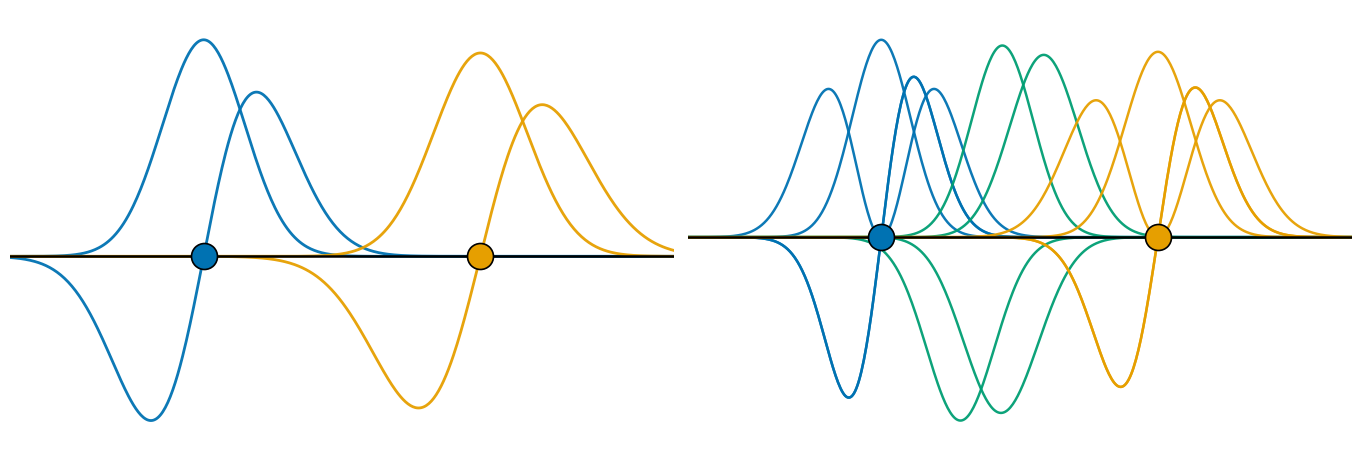

In [61]:
import numpy as np
import matplotlib.pyplot as plt


def gbf(
    x: np.ndarray,
    exp: float,
    pot: int,
    pos: float = 0.0,
    amplitude: float = 1.0,
) -> np.ndarray:
    x_shift = x - pos
    return amplitude * (x_shift**pot) * np.exp(-exp * x_shift**2)


def normalize_l2(phi: np.ndarray, dx: float) -> np.ndarray:
    norm = np.sqrt(np.sum(phi**2) * dx)
    if norm == 0.0:
        return phi
    return phi / norm


def padded_limits(ymin: float, ymax: float, pad_frac: float = 0.08) -> tuple[float, float]:
    if ymax == ymin:
        delta = 1.0 if ymax == 0.0 else 0.1 * abs(ymax)
        return ymin - delta, ymax + delta
    pad = pad_frac * (ymax - ymin)
    return ymin - pad, ymax + pad


# Two atoms on the x-axis
distance = 5
x_a = -distance / 2.0
x_b = distance / 2.0
x_edge = 0.5 * (x_a + x_b)

x = np.linspace(-2 * distance, 2 * distance, 900)
dx = x[1] - x[0]

# GBF basis parameters: (exp, pot, amplitude)
basis_a_specs = [
    (0.9, 0, 0.20),
    (0.55, 1, 0.38),
]
basis_b_specs = [
    (0.7, 0, 0.12),
    (0.40, 1, 0.22),
]

basis_a = [gbf(x, exp=e, pot=p, pos=x_a, amplitude=a) for e, p, a in basis_a_specs]
basis_b = [gbf(x, exp=e, pot=p, pos=x_b, amplitude=a) for e, p, a in basis_b_specs]

# Normalize all basis functions by their L2 norm
basis_a = [normalize_l2(phi, dx) for phi in basis_a]
basis_b = [normalize_l2(phi, dx) for phi in basis_b]

# Build all pairwise combinations explicitly
all_aa = [
    (f"A{i + 1}A{j + 1}", basis_a[i] * basis_a[j])
    for i in range(len(basis_a))
    for j in range(len(basis_a))
]
all_ab = [
    (f"A{i + 1}B{j + 1}", basis_a[i] * basis_b[j])
    for i in range(len(basis_a))
    for j in range(len(basis_b))
]
all_bb = [
    (f"B{i + 1}B{j + 1}", basis_b[i] * basis_b[j])
    for i in range(len(basis_b))
    for j in range(len(basis_b))
]

# Normalize all basis-function products by their L2 norm
all_aa = [(label, normalize_l2(term, dx)) for label, term in all_aa]
all_ab = [(label, normalize_l2(term, dx)) for label, term in all_ab]
all_bb = [(label, normalize_l2(term, dx)) for label, term in all_bb]

terms_aa = [term for _, term in all_aa]
terms_ab = [term for _, term in all_ab]
terms_bb = [term for _, term in all_bb]

field_aa = np.sum(terms_aa, axis=0)
field_ab = np.sum(terms_ab, axis=0)
field_bb = np.sum(terms_bb, axis=0)

basis_values = np.concatenate(basis_a + basis_b)
term_values = np.concatenate(terms_aa + terms_ab + terms_bb)
basis_ylim = padded_limits(float(np.min(basis_values)), float(np.max(basis_values)))
term_ylim = padded_limits(float(np.min(term_values)), float(np.max(term_values)))

# Okabe-Ito colorblind-safe palette
color_a = "#0072B2"  # blue
color_b = "#E69F00"  # orange
color_ab = "#009E73"  # bluish green

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), constrained_layout=True)

# Panel 1: 1D atom-centered basis functions
ax = axes[0]
for phi in basis_a:
    ax.plot(x, phi, color=color_a, lw=2.0, alpha=0.95)
for phi in basis_b:
    ax.plot(x, phi, color=color_b, lw=2.0, alpha=0.95)
ax.axhline(0.0, color="black", lw=1.8, zorder=10)
ax.scatter(
    [x_a],
    [0.0],
    s=350,
    c=[color_a],
    edgecolors="black",
    linewidths=1.2,
    zorder=11,
)
ax.scatter(
    [x_b],
    [0.0],
    s=350,
    c=[color_b],
    edgecolors="black",
    linewidths=1.2,
    zorder=11,
)
ax.set_ylim(*basis_ylim)

# Panel 2: all individual combinations for AA, AB, and BB
ax = axes[1]
for _, term in all_aa:
    ax.plot(x, term, color=color_a, lw=1.8, alpha=0.95)
for _, term in all_ab:
    ax.plot(x, term, color=color_ab, lw=1.8, alpha=0.95)
for _, term in all_bb:
    ax.plot(x, term, color=color_b, lw=1.8, alpha=0.95)
ax.axhline(0.0, color="black", lw=1.8, zorder=10)
ax.scatter(
    [x_a],
    [0.0],
    s=350,
    c=[color_a],
    edgecolors="black",
    linewidths=1.2,
    zorder=11,
)
ax.scatter(
    [x_b],
    [0.0],
    s=350,
    c=[color_b],
    edgecolors="black",
    linewidths=1.2,
    zorder=11,
)
ax.set_ylim(*term_ylim)

for a in axes:
    a.set_xlim(-1.2 * distance, 1.2 * distance)
    a.set_xticks([])
    a.set_yticks([])
    for spine in a.spines.values():
        spine.set_visible(False)

plt.savefig("edge_centered_basis_products_2d.pdf", dpi=300)
plt.show()

In [53]:
def argmax_x(field: np.ndarray, xx: np.ndarray) -> float:
    idx = int(np.argmax(field))
    return float(xx[idx])


print("AA peak x:", argmax_x(field_aa, x))
print("AB peak x:", argmax_x(field_ab, x))
print("BB peak x:", argmax_x(field_bb, x))
print("Expected AB midpoint x:", x_edge)
print("AB term peak x values:")
for label, term in all_ab:
    print(f"  {label}: {argmax_x(term, x): .4f}")

AA peak x: -2.912124582869856
AB peak x: 0.5139043381535036
BB peak x: 4.157953281423804
Expected AB midpoint x: 0.0
AB term peak x values:
  A1B1: -0.4516
  A1B2:  3.5662
  A2B1:  0.5139
  A2B2: -3.6596
